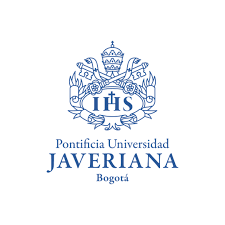
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Parcial: **Calidad del Agua**

Autor: Sebastian Angulo Vergara

Profesor: Jhon Corredor Franco

Fecha de Inicio: 14/04/2026

Fecha actual: 

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

In [1]:
# Levantamiento de variables de entorno pip
import os

import sys

sys.path.append('/usr/lib/python3/dist-packages/')

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init('/Almacen/Spark')

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *

**Levantamiento de sesión SPARK**

In [2]:
configura = SparkConf()
configura.set('spark.scheduler.mode', 'FAIR')
configura.set('spark.scheduler.allocation','/Almacen/Spark/conf/fairscheduler.xml')
configura.setMaster('spark://10.43.97.166:7077')
configura.setAppName('Calidad_Agua_Angulo')

sparkAngulo = SparkSession.builder.config(conf=configura).getOrCreate()

print("Sesion creada: ProcesamientoDatos")

sparkAngulo

Sesion creada: ProcesamientoDatos


## **2.- Carga de datos**

In [3]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El acceso se hara desde el sistema de ficheros Hadoop HDFS
df00 = sparkAngulo.read.format("csv").option("header","true").load("../Parcial/Data/waterquality.csv")
df00.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

In [4]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

**Se presenta las estadísticas de los datos a continuación:**

In [5]:
for valor in df00.columns:
  
  df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+---------

## **Visualización de los DATOS NULOS**
Cantidad de Valores Nulos o Imposibles

In [6]:
# Se cuentan valores nulos, NaN y también strings "NA" que el CSV puede cargar como texto
df00.select([
    F.count(F.when(
        F.isnan(c) | F.col(c).isNull() | (F.col(c) == "NA"), c
    )).alias(c)
    for c in df00.columns
]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   5|  2|  0|          30|  6|                  2|            82|            39|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



* Se observa que no hay datos nulos o imposibles
* Se procede a Graficar cada una de las dimensiones
* Se crea una vista para ser usada en las visualizaciones
* df00.createOrReplaceTempView("df00_sql")
* df01 = sparkS.sql('''Select * from df00_sql where TEMP is not null and

In [7]:
# Los datos del CSV pueden contener el string "NA" en lugar de valores nulos reales.
# Se eliminan filas donde algún parámetro clave sea nulo, NaN o el texto "NA".
df01 = df00.filter(
    (df00["DO"].isNotNull())               & (df00["DO"] != "NA") &
    (df00["pH"].isNotNull())               & (df00["pH"] != "NA") &
    (df00["CONDUCTIVITY"].isNotNull())     & (df00["CONDUCTIVITY"] != "NA") &
    (df00["BOD"].isNotNull())              & (df00["BOD"] != "NA") &
    (df00["NITRATE_N_NITRITE_N"].isNotNull()) & (df00["NITRATE_N_NITRITE_N"] != "NA") &
    (df00["FECAL_COLIFORM"].isNotNull())   & (df00["FECAL_COLIFORM"] != "NA")
)

Se verifica la Cantidad de Valores Nulos o Imposibles

In [8]:
# Se verifica que ya no queden nulos ni strings "NA" tras el filtrado
df01.select([
    F.count(F.when(
        F.isnan(c) | F.col(c).isNull() | (F.col(c) == "NA"), c
    )).alias(c)
    for c in df01.columns
]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



## **Tratamiento de datos**

In [9]:
df00.dtypes
##Se procede a cambiar los tipos de datos
df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))
df00.dtypes


##Se elimina la columna TOTAL_COLIFORM
df01 = df00.drop('TOTAL_COLIFORM')
df01.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

## **Creación de Tablas para Visualizar los Datos**

- Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

- df01.createOrReplaceTempView("df01_sql")

- Se crea una consulta por cada parámetro DO
- do_parametro = sparkS.sql("Select DO from df01_sql")
- Se hace una consulta para crear el vector de la tabla por cada parámetro
- do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()

- pH
- CONDUCTIVITY
- BOD
- NITRATE_N_NITRITE_N
- FECAL_COLIFORM 

In [10]:
# Se crea la vista temporal y se extrae cada parámetro como lista Python
# usando la función lambda sobre el RDD
df01.createOrReplaceTempView("df01_sql")

do_parametro = sparkAngulo.sql("Select DO from df01_sql")
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()

ph_parametro = sparkAngulo.sql("Select pH from df01_sql")
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.pH).collect()

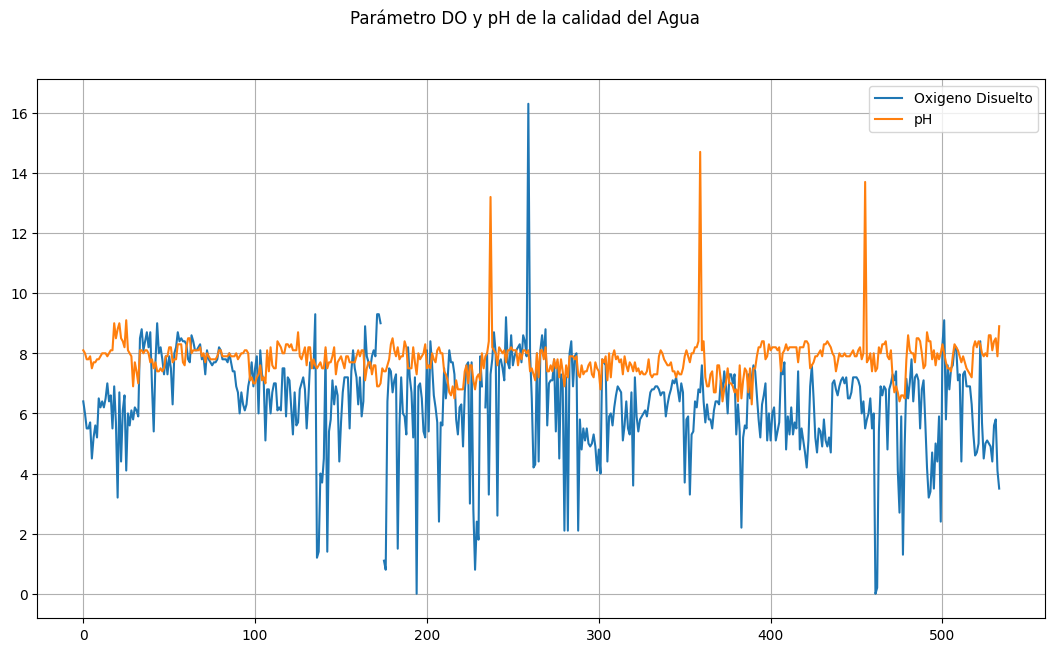

In [11]:
###Grafica Los parámetros para conocer sus características: DO y PH

tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), ph_parametro, label='pH')
fig.suptitle('Parámetro DO y pH de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

In [12]:
# Se crea una consulta por cada parámetro usando la función lambda
df01.createOrReplaceTempView("df01_sql")

BOD_parametro = sparkAngulo.sql("Select BOD from df01_sql")
BOD_parametro = BOD_parametro.rdd.map(lambda fila: fila.BOD).collect()

NIT_parametro = sparkAngulo.sql("Select NITRATE_N_NITRITE_N from df01_sql")
NIT_parametro = NIT_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()

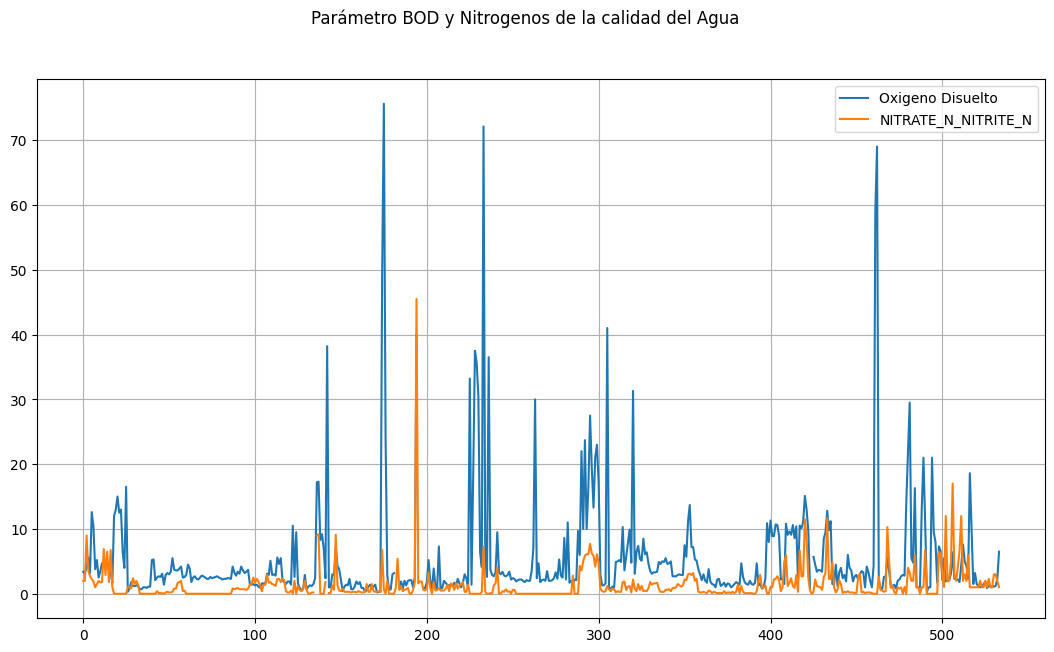

In [13]:
###Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos

tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), BOD_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), NIT_parametro, label='NITRATE_N_NITRITE_N')
fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

In [14]:
# Se crea una consulta por cada parámetro usando la función lambda
df01.createOrReplaceTempView("df01_sql")

COND_parametro = sparkAngulo.sql("Select CONDUCTIVITY from df01_sql")
COND_parametro = COND_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()

FC_parametro = sparkAngulo.sql("Select FECAL_COLIFORM from df01_sql")
FC_parametro = FC_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()

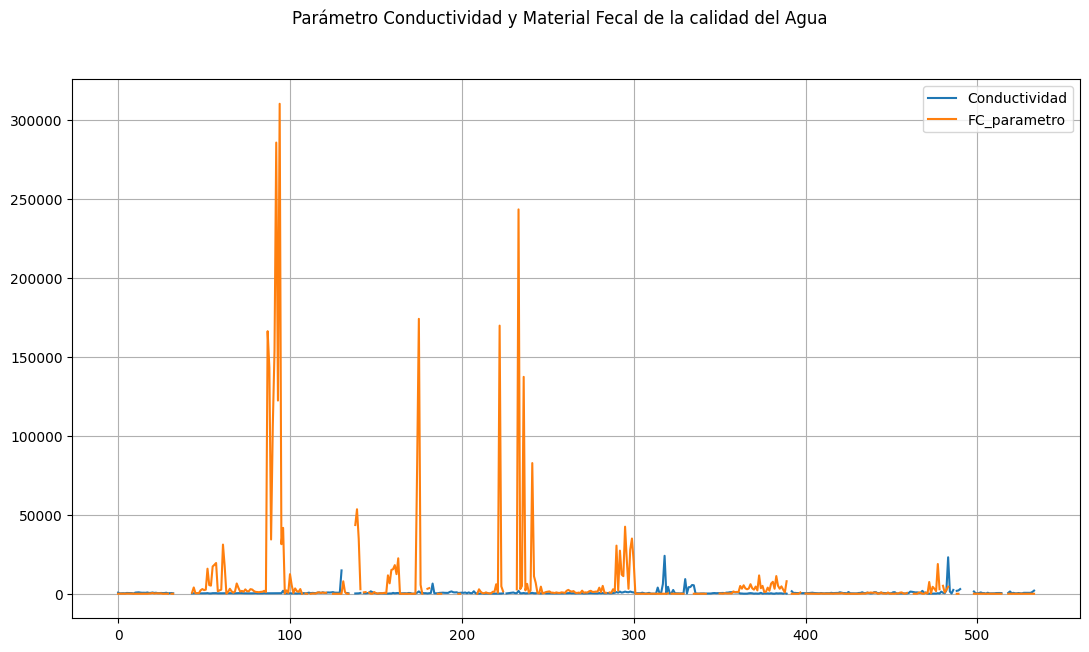

In [15]:
###Grafica Los parámetros para conocer sus características: FC y Conductividad

tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), COND_parametro, label='Conductividad')
ax1.plot(range(0,tam), FC_parametro, label='FC_parametro')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

## **Análisis de Correlación entre Parámetros**

Antes de definir los rangos de calidad, se analiza la correlación entre los parámetros numéricos del dataset. Esto permite identificar si alguna variable está redundando información con otra, lo cual es relevante para entender la independencia de los indicadores usados en el cálculo del WQI.

Una correlación alta entre dos parámetros indica que podrían medir fenómenos relacionados en los ríos de la India, mientras que una correlación baja confirma que cada uno aporta información independiente al índice final.

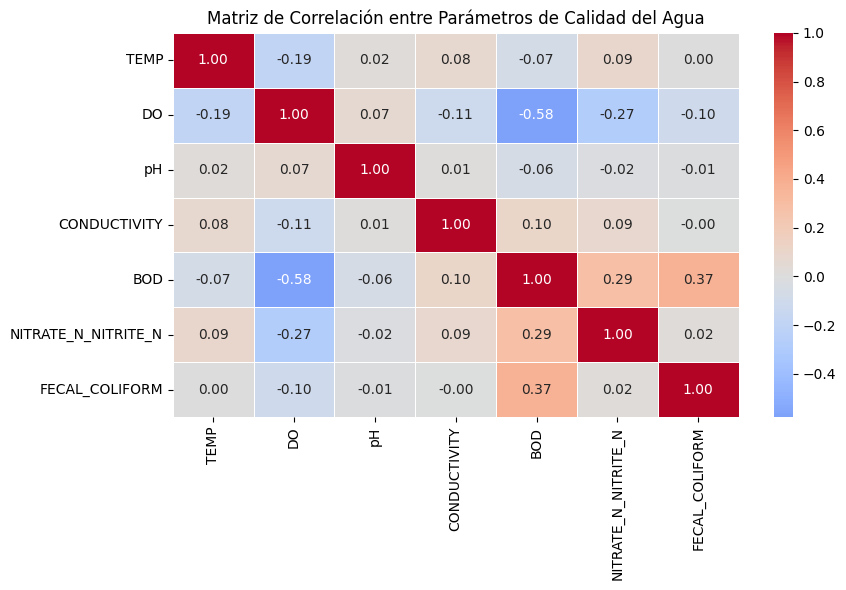

In [16]:
# Se convierten las columnas numéricas de df01 a pandas para calcular la correlación
# Solo se toman las columnas que participan en el cálculo del WQI
columnas_num = ['TEMP', 'DO', 'pH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM']

df01_pandas = df01.select(columnas_num).toPandas()

# Se calcula la matriz de correlación de Pearson
correlacion = df01_pandas.corr()

# Visualización como mapa de calor
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matriz de Correlación entre Parámetros de Calidad del Agua', fontsize=12)
plt.tight_layout()
plt.show()

Función definida por el usuario para definir el rango de calidad de agua según el pH
- Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

In [17]:
df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).

       when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).

       when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).

       when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

### Función definida por el usuario para definir el rando de la calidad del agua según DO

In [18]:
df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
    when((df01.DO>=5.1) & (df01.DO<6.0), 80).
    when((df01.DO>=4.1) & (df01.DO<5.0), 60).
    when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

### Función definida por el usuario para definir el rango de la calidad del agua según COND

In [19]:
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
    when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
    when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
    when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

### Función definida por el usuario para definir el rango de la calidad del agua según BOD

In [20]:
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
    when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
    when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
    when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

### Función definida por el usuario para definir el rango de la calidad del agua según NITRATE_N_NITRITE_N
    -  100: Agua Dulce
    -  80: Agua Moderada
    -  60: Agua Dura
    -  40: Agua muy Dura

In [21]:
df02 = df02.withColumn("qrNIT", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
    when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
    when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
    when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

### Función definida por el usuario para definir el rango de la calidad del agua según el Material Fecal
  -   100: Agua Dulce
  -   80: Agua Moderada
  -   60: Agua Dura
  -   40: Agua muy Dura

In [22]:
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
    when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
    when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
    when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua


In [23]:
##A continuación se hace una inspección en general del df02
df02.show(10)
##Nombre de Columnas
df02.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+-----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNIT|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+-----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80|  100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80|  100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80|  100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNIT',
 'qrFecal']

## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

In [24]:
###Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad
df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNIT", F.round(df03.qrNIT*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

df03.show(10)


+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+-----+-------+----+-----+-----+----+----+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNIT|qrFecal| wpH|  wDO|wCOND|wBOD|wNIT|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+-----+-------+----+-----+-----+----+----+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80|  100|    100|16.5| 28.1|  0.0|0.72| 2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80|  100|     60|16.5| 28.1| 9.36|0.72| 2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4

### Calculo del Índice de Calidad del Agua
   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

In [25]:
df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNIT+df03.wFecal+df03.wDO,3))
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+-----+-------+----+-----+-----+----+----+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNIT|qrFecal| wpH|  wDO|wCOND|wBOD|wNIT|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+-----+-------+----+-----+-----+----+----+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80|  100|    100|16.5| 28.1|  0.0|0.72| 2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80|  100|     60|16.5| 28.1| 9.36|0.72| 2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTR

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***

In [26]:
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
.when((df04.WQI>=25) & (df04.WQI<50),'Buena')
.when((df04.WQI>=50) & (df04.WQI<75),'Baja')
.when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
.otherwise('Inadecuada'))
df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+-----+-------+----+-----+-----+----+----+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNIT|qrFecal| wpH|  wDO|wCOND|wBOD|wNIT|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+-----+-------+----+-----+-----+----+----+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80|  100|    100|16.5| 28.1|  0.0|0.72| 2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80|  100|     60|16.5| 28.1| 9.36|0.72| 2.8| 16.86|74.34|    Baja|


## **Análisis de Distribución de Categorías de Calidad por Estado**

Con la columna `CALIDAD` ya calculada, se analiza cuántos registros caen en cada categoría de calidad de agua por estado. Esto permite identificar cuáles estados de la India concentran las peores o mejores condiciones de agua según el WQI, y da una lectura más directa que el valor numérico puro antes de verlo en el mapa.

+----------------+---------+--------+
|           STATE|  CALIDAD|cantidad|
+----------------+---------+--------+
|  ANDHRA PRADESH|     Baja|      21|
|  ANDHRA PRADESH| Muy_Baja|      10|
|  ANDHRA PRADESH|    Buena|       8|
|  ANDHRA PRADESH|Excelente|       4|
|           ASSAM|     Baja|      18|
|           ASSAM| Muy_Baja|       2|
|           ASSAM|    Buena|       2|
|           BIHAR|     Baja|      37|
|           BIHAR|    Buena|      21|
|           BIHAR|Excelente|       3|
|    CHHATTISGARH|    Buena|       4|
|           DELHI|Excelente|       3|
|           DELHI|    Buena|       1|
|             GOA|     Baja|      22|
|             GOA|    Buena|      10|
|             GOA|Excelente|       3|
|             GOA| Muy_Baja|       1|
|         GUJARAT|    Buena|      15|
|         GUJARAT|     Baja|       3|
|         GUJARAT| Muy_Baja|       2|
|         GUJARAT|Excelente|       1|
|HIMACHAL PRADESH|     Baja|      10|
|HIMACHAL PRADESH| Muy_Baja|       6|
|       KARN

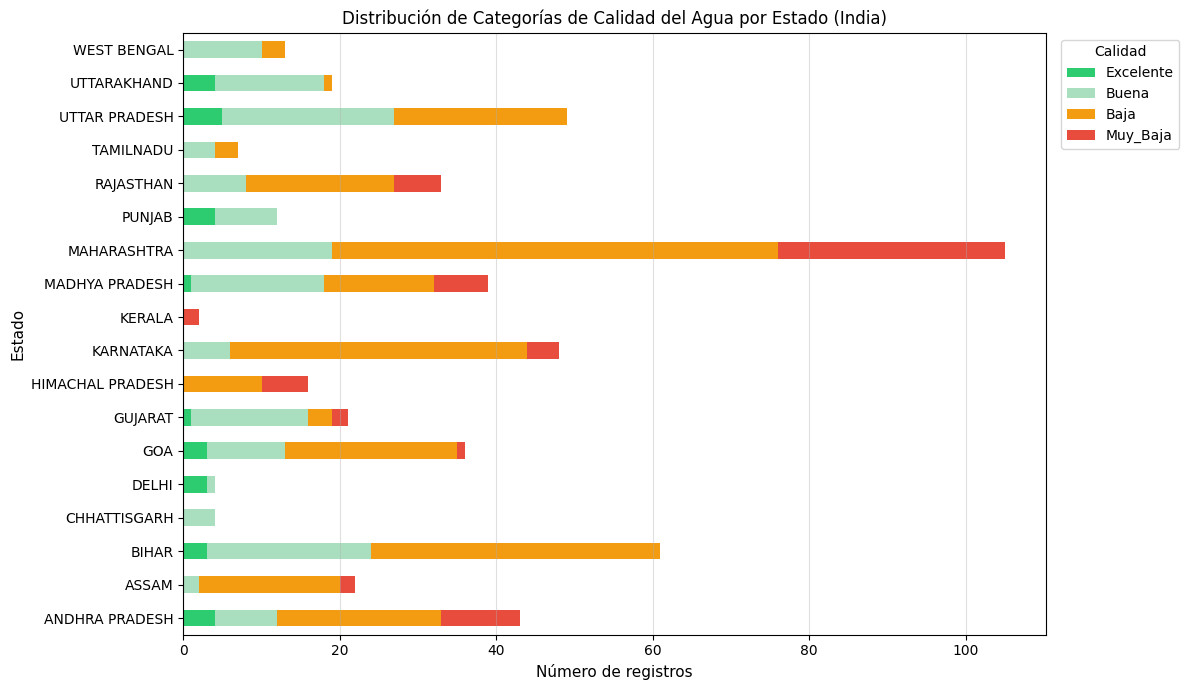

In [27]:
# Se agrupan los registros por estado y categoría de calidad para contar frecuencias
df05.createOrReplaceTempView("df05_sql")

calidad_estado = sparkAngulo.sql("""
    SELECT STATE, CALIDAD, COUNT(*) as cantidad
    FROM df05_sql
    GROUP BY STATE, CALIDAD
    ORDER BY STATE, cantidad DESC
""")

calidad_estado.show(30)

# Se convierte a pandas para graficar
df_calidad_pd = calidad_estado.toPandas()

# Tabla pivote: filas = estados, columnas = categorías de calidad
pivot = df_calidad_pd.pivot_table(
    index='STATE', columns='CALIDAD', values='cantidad', fill_value=0
)

# Orden de categorías de mejor a peor
orden_categorias = ['Excelente', 'Buena', 'Baja', 'Muy_Baja', 'Inadecuada']
orden_categorias = [c for c in orden_categorias if c in pivot.columns]
pivot = pivot[orden_categorias]

# Paleta de colores acorde al significado (verde=bueno, rojo=malo)
colores = {'Excelente': '#2ecc71', 'Buena': '#a9dfbf',
           'Baja': '#f39c12', 'Muy_Baja': '#e74c3c', 'Inadecuada': '#922b21'}
colores_grafica = [colores.get(c, '#95a5a6') for c in orden_categorias]

fig, ax = plt.subplots(figsize=(12, 7))
pivot.plot(kind='barh', stacked=True, ax=ax, color=colores_grafica)

ax.set_title('Distribución de Categorías de Calidad del Agua por Estado (India)', fontsize=12)
ax.set_xlabel('Número de registros', fontsize=11)
ax.set_ylabel('Estado', fontsize=11)
ax.legend(title='Calidad', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='x', alpha=0.4)
plt.show()

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

In [28]:
colEstado = 'STATE'
valNomnbres = df05.select(colEstado).distinct().collect()
valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### **Se cargan los datos de los mapas disponibles**

- Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta

In [29]:
##!pip install geopandas

In [30]:
import geopandas as gpd

rutaMapas = "../Parcial/Data/Indian_States.shp"
## Se carga un objeto dataframe de los datos comprimidos de los mapas
gpd01 = gpd.read_file(rutaMapas)

## Se visualiza el tipo de dataframe que da geopandas y las columnas
print(type(gpd01))
gpd01.columns

<class 'geopandas.geodataframe.GeoDataFrame'>


Index(['st_nm', 'geometry'], dtype='object')

In [31]:
#Se visualizan los nombres de la columna de los estados "st_nm"
gpd01["st_nm"].unique()

### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan
### con los nombres de los estados del dataframe de datos inicial
gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                       'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                       'Daman & Diu': 'Daman Diu',
                       'Jammu & Kashmir': 'Jammu Kashmir',
                       'NCT of Delhi' : 'Delhi'})
gpd02["st_nm"].unique()

array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan en formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [32]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+-----+-------+----+-----+-----+----+----+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNIT|qrFecal| wpH|  wDO|wCOND|wBOD|wNIT|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+-----+-------+----+-----+-----+----+----+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80|  100|    100|16.5| 28.1|  0.0|0.72| 2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80|  100|     60|16.5| 28.1| 9.36|0.72| 2.8| 16.86|74.34|    Baja|
|    

In [33]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **Se pinta el mapa inicial**

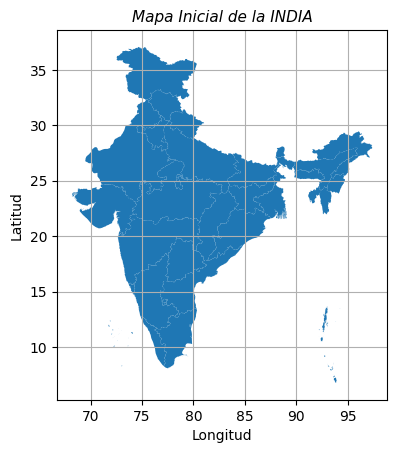

In [34]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [35]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


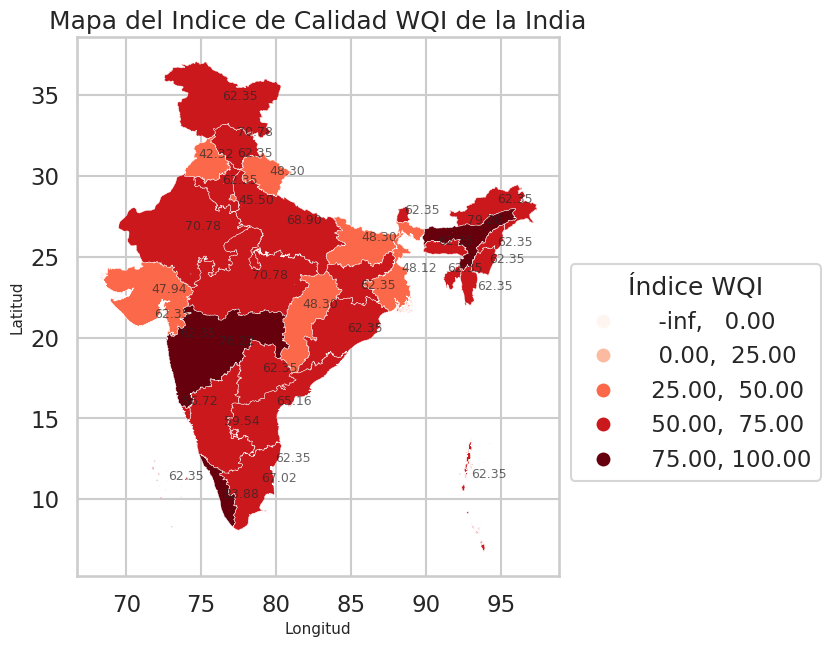

In [36]:
# Los estados sin datos del CSV quedan con WQI nulo tras el merge.
# Se imputan con la mediana del WQI para poder pintarlos en el mapa.
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

# Estilo visual del mapa con seaborn
sns.set_context("talk")
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12, 7))

# Se colorea cada estado según su rango de WQI definido anteriormente
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0, 25, 50, 75, 100]},
          legend=True, linewidth=0.3)

leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1, 0.6))

# Se anota el valor WQI sobre el centroide de cada estado
# adjust_text evita superposición entre etiquetas
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)

adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

### **Histograma de WQI por Estado**

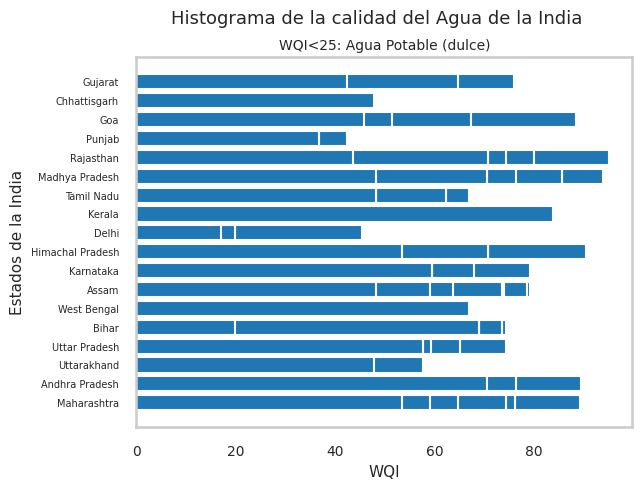

In [37]:
df06.createOrReplaceTempView("df06_sql")

# Se seleccionan los nombres de los estados
Estados = sparkAngulo.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkAngulo.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados, wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

### **Creación de Modelo: Calidad de Agua en la India**

Para predecir el WQI se construye una red neuronal densa con Keras:
- Las columnas de rangos de calidad (qr*) son las variables de entrada
- El WQI calculado es la variable objetivo de regresión
- Los datos se dividen 80% entrenamiento / 20% prueba con Scikit-Learn
- Se usa una arquitectura de tres capas ocultas con activación ReLU
- El optimizador ADAM minimiza el error cuadrático medio (MSE)

In [38]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNIT',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNIT',
 'wFecal',
 'WQI',
 'CALIDAD']

In [39]:
# Variables independientes: rangos de calidad de cada parámetro
dfcalidad = df06.select('qrPH', 'qrDO', 'qrCOND', 'qrBOD', 'qrNIT', 'qrFecal')

# Variable dependiente: índice WQI a predecir
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+-----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNIT|qrFecal|
+----+----+------+-----+-----+-------+
| 100| 100|     0|   80|  100|    100|
| 100| 100|    40|   80|  100|     60|
| 100|  80|     0|   80|  100|     60|
| 100|  80|     0|   80|  100|     60|
| 100|  80|    40|   80|  100|     80|
+----+----+------+-----+-----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



In [40]:
from sklearn.model_selection import train_test_split

# División estratificada: 80% entrenamiento, 20% prueba
# random_state=1 fija la semilla para que el experimento sea reproducible
dataTrain, dataTest, predTrain, predTest = train_test_split(
    dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1
)

In [41]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


In [42]:
##!pip install keras

In [43]:
!pip install TensorFlow

Defaulting to user installation because normal site-packages is not writeable


In [44]:
## Se importa la instancia TensorFlow/Keras
import keras
from keras.models import Sequential
from keras.layers import Dense

In [45]:
epocas = 200
lote = 81

# Red neuronal secuencial con 3 capas ocultas de 350 neuronas cada una.
# ReLU introduce no-linealidad; la capa de salida es lineal por ser regresión.
modelo01 = Sequential()
modelo01.add(Dense(350, input_dim=6, activation='relu'))
modelo01.add(Dense(350, activation='relu'))
modelo01.add(Dense(350, activation='relu'))
modelo01.add(Dense(1, activation='linear'))

/home/estudiante/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
# ADAM adapta la tasa de aprendizaje por parámetro, lo que acelera la convergencia
# MSE penaliza más los errores grandes, adecuado para regresión continua
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [47]:
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Se entrena el modelo con los datos de entrenamiento
# verbose por defecto muestra el progreso por época
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1999.4908 - mse: 1999.4908
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 145.0520 - mse: 145.0520
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 96.2316 - mse: 96.2316  
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 65.3908 - mse: 65.3908 
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 38.8669 - mse: 38.8669
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 16.7573 - mse: 16.7573
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9.3989 - mse: 9.3989
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.6631 - mse: 4.6631
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.7120 - mse: 2.7120
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.7867 - mse: 1.7867
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1072 - mse: 1.1072
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6152 - mse: 0.6152
Epoch 13/200
6/6 ━━━━━━━━━━━

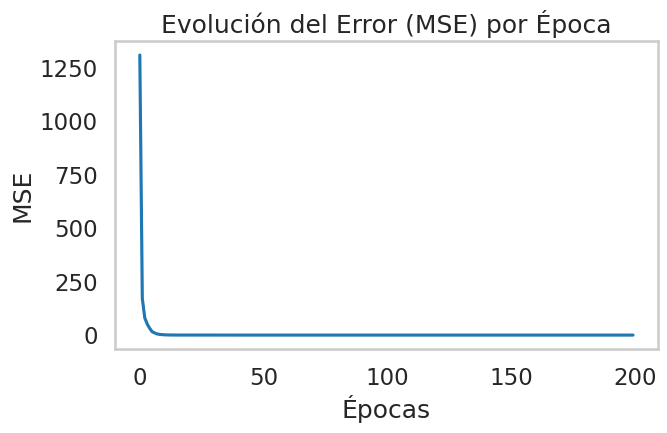

In [49]:
# La curva de pérdida muestra cómo evoluciona el MSE durante el entrenamiento
plt.figure(figsize=(7, 4))
plt.plot(ejecutarK.history['loss'])
plt.title("Evolución del Error (MSE) por Época")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.grid()
plt.show()

In [50]:
# Predicción sobre el conjunto de entrenamiento para evaluar el ajuste del modelo
predModelo01_Train = modelo01.predict(dataTrain)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


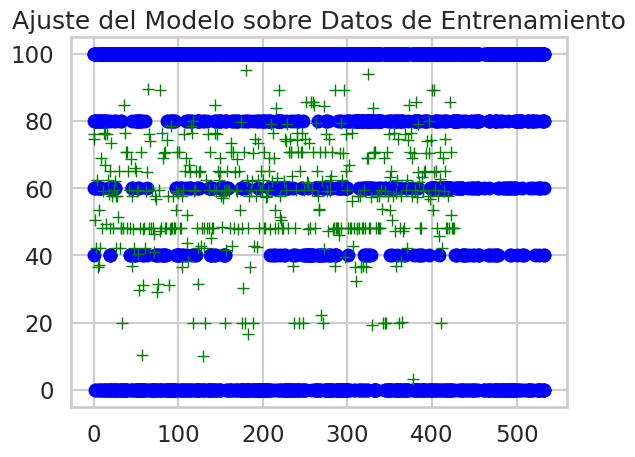

In [51]:
# Comparación visual: puntos azules = datos reales, cruces verdes = predicción
plt.plot(dataTrain, 'bo', predModelo01_Train, 'g+')
plt.title("Ajuste del Modelo sobre Datos de Entrenamiento")
plt.show()

## **Conclusiones**

Se hizo uso de PySpark para diagnosticar la calidad del agua en los ríos de la India. 

**1. Preprocesamiento y calidad del dataset**
El dataset original presentaba valores ausentes codificados como el string `"NA"`, lo que requirió un tratamiento específico adicional al manejo estándar de nulos en PySpark. Tras la limpieza, los datos resultaron consistentes y aptos para el cálculo del WQI.

**2. Correlación entre parámetros**
El análisis de correlación mostró que la mayoría de los parámetros presentan baja correlación entre sí, lo que confirma que cada indicador aporta información independiente al índice de calidad. Esto valida el enfoque multi-paramétrico del WQI y justifica el uso de todos los parámetros disponibles en el cálculo.

**3. Distribución geográfica de la calidad**
La distribución de categorías por estado reveló una heterogeneidad importante en la calidad del agua a lo largo del territorio indio. Los estados con mayor actividad agrícola e industrial tienden a presentar valores de WQI más elevados, reflejando mayor concentración de nitratos y material fecal como principales factores de degradación.

**4. Índice WQI como herramienta de síntesis**
El WQI calculado a partir de los pesos bibliográficos de referencia (DO con mayor peso 0.281, seguido de Conductividad con 0.234 y pH con 0.165) permitió condensar seis parámetros en un único indicador interpretable. Es importante reiterar que, como señala la literatura, la confiabilidad del índice aumenta con mayor volumen de datos y períodos de medición más amplios.

**5. Modelo de predicción con Keras**
La red neuronal densa de tres capas ocultas (350 neuronas cada una, activación ReLU) entrenada con los rangos de calidad como variables de entrada logró aproximar el WQI. La curva de pérdida descendente durante el entrenamiento indica que el modelo convergió correctamente. No obstante, dado el tamaño limitado del dataset, los resultados deben interpretarse como una demostración metodológica más que como un predictor de producción.

**6. Pertinencia del enfoque PAVD**
Aunque el volumen del dataset de ríos de la India es manejable en entornos tradicionales, la implementación sobre PySpark y el cluster demuestra la escalabilidad del enfoque: el mismo pipeline puede aplicarse sobre millones de registros de sensores en tiempo real sin cambios estructurales en el código.